In [24]:
# AI-Based Water Quality Monitoring System

### Objective
#Predict whether water is potable or non-potable using Machine Learning.

### Dataset
#Water Potability Dataset (Kaggle)

### Algorithms
#- Logistic Regression
#- Decision Tree
#- Random Forest
#- SVM

In [25]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import pickle

In [26]:
#Load Dataset
df = pd.read_csv("water_potability.csv")

print("Dataset Loaded Successfully!\n")

df.head()

Dataset Loaded Successfully!



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [27]:
#Dataset Overview

print("Shape :", df.shape)

print("\nColumns\n")
print(df.columns)

print("\nDataset Information\n")

df.info()

print("\nStatistical Summary\n")

display(df.describe())

Shape : (3276, 10)

Columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

Dataset Information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB

Statistical Summary



,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


,Missing Values,Percentage
ph,491,14.99
Hardness,0,0.00
Solids,0,0.00
Chloramines,0,0.00
Sulfate,781,23.84
Conductivity,0,0.00
Organic_carbon,0,0.00
Trihalomethanes,162,4.95
Turbidity,0,0.00
Potability,0,0.00


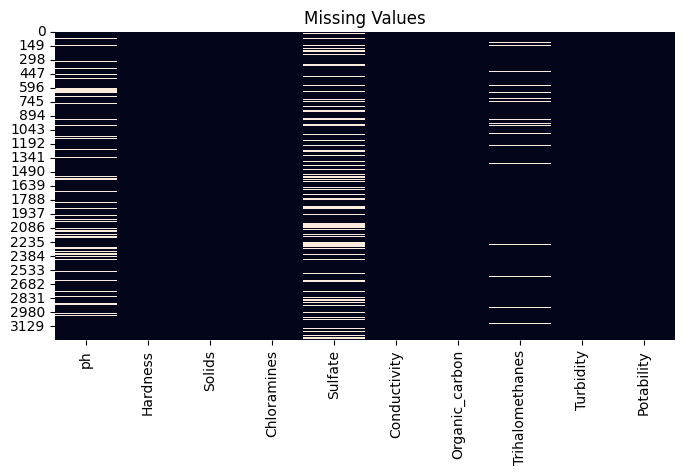

In [28]:
#Missing Value Analysis
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

display(missing)

plt.figure(figsize=(8,4))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values")

plt.show()

In [29]:
#Data Cleaning
imputer = SimpleImputer(strategy="median")

df[df.columns] = imputer.fit_transform(df)

print("Missing Values After Cleaning")

print(df.isnull().sum())

Missing Values After Cleaning
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


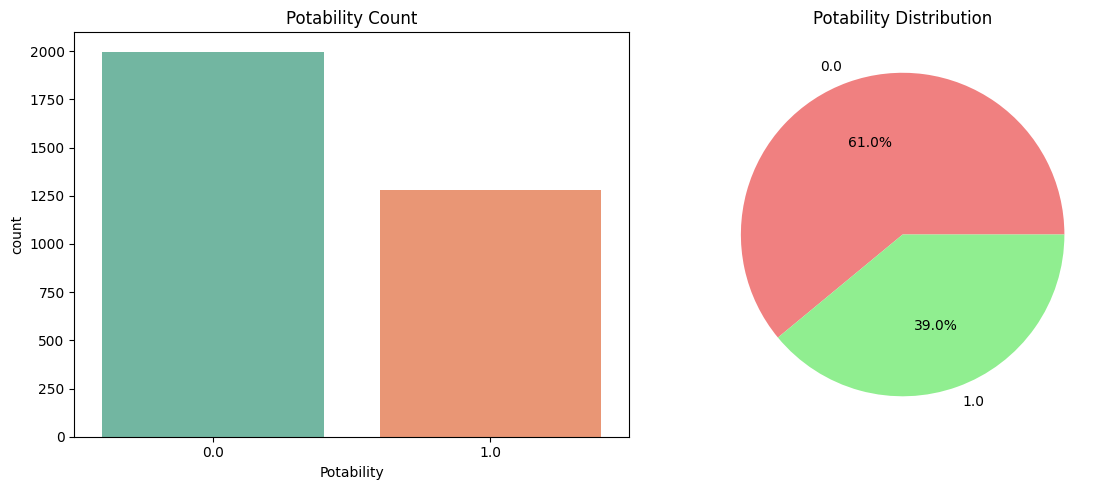

In [30]:
#Target Variable Analysis
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.countplot(
    data=df,
    x="Potability",
    palette="Set2",
    ax=ax[0]
)

ax[0].set_title("Potability Count")

df["Potability"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["lightcoral","lightgreen"],
    ax=ax[1]
)

ax[1].set_ylabel("")

ax[1].set_title("Potability Distribution")

plt.tight_layout()

plt.show()

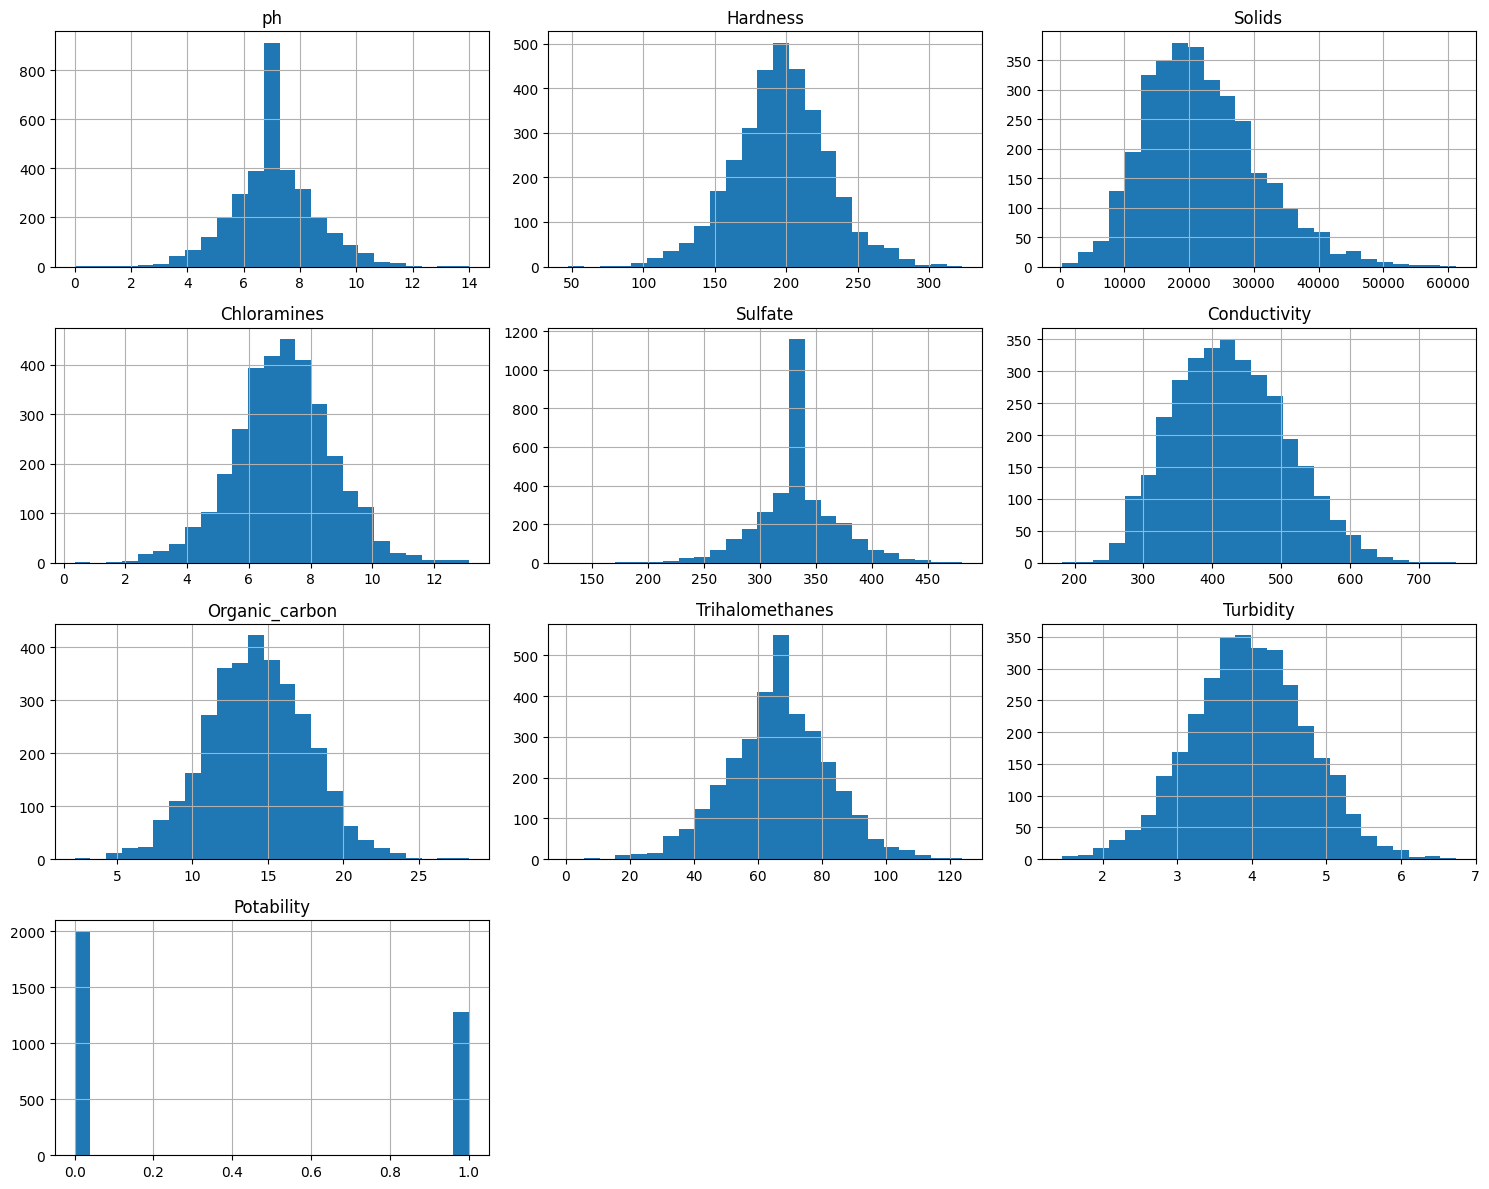

In [31]:
#Feature Distribution
df.hist(figsize=(15,12), bins=25)

plt.tight_layout()

plt.show()

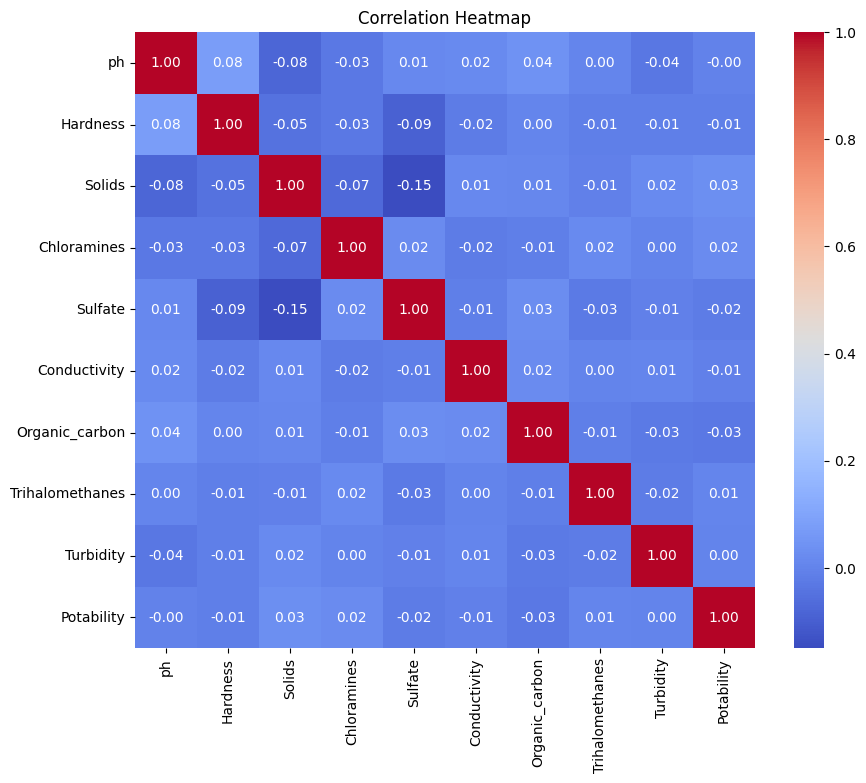

In [32]:
#Correlation Analysis
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [33]:
#Data Preprocessing
X = df.drop("Potability", axis=1)

y = df["Potability"]

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(2620, 9)
(656, 9)


In [34]:
#Model Training
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.609756,0.000000,0.000000,0.000000
1,Decision Tree,0.596037,0.481328,0.453125,0.466801
2,Random Forest,0.658537,0.631148,0.300781,0.407407
3,Support Vector Machine,0.670732,0.704082,0.269531,0.389831


,Model,Accuracy,Precision,Recall,F1 Score
3,Support Vector Machine,0.670732,0.704082,0.269531,0.389831
2,Random Forest,0.658537,0.631148,0.300781,0.407407
0,Logistic Regression,0.609756,0.000000,0.000000,0.000000
1,Decision Tree,0.596037,0.481328,0.453125,0.466801


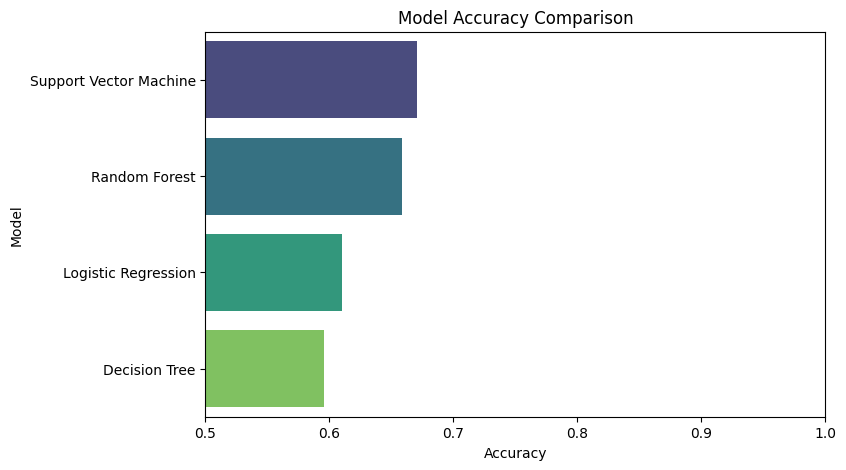

In [35]:
#Model Comparison
results = results.sort_values("Accuracy", ascending=False)

display(results)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0.5,1)

plt.show()

In [36]:
best_model = results.iloc[0]

print("="*40)
print("Best Performing Model")
print("="*40)

print(best_model)

Best Performing Model
Model        Support Vector Machine
Accuracy                   0.670732
Precision                  0.704082
Recall                     0.269531
F1 Score                   0.389831
Name: 3, dtype: object


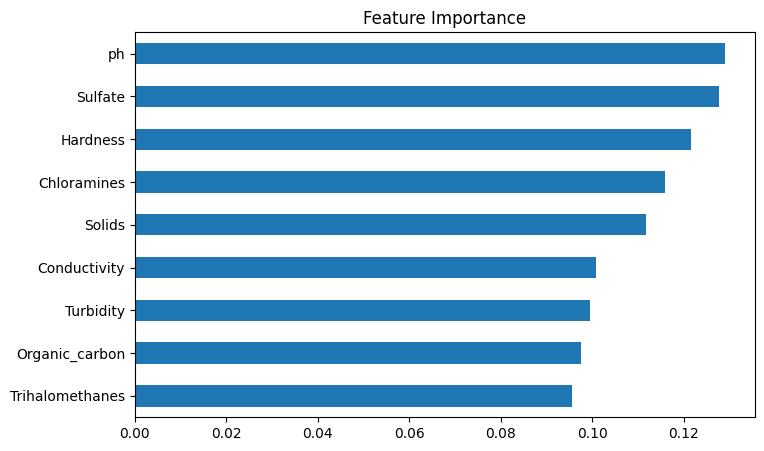

In [37]:
#Feature Importance
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=df.drop("Potability",axis=1).columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Importance")

plt.show()

In [38]:
#Save Trained Model
pickle.dump(rf, open("best_model.pkl","wb"))

pickle.dump(scaler, open("scaler.pkl","wb"))
pickle.dump(imputer, open("imputer.pkl", "wb"))

print("Model Saved Successfully!")

Model Saved Successfully!


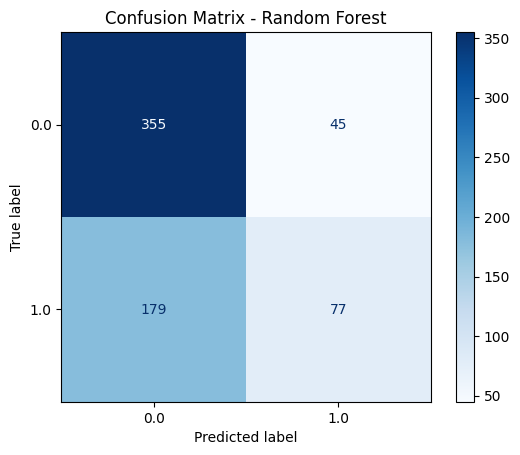

              precision    recall  f1-score   support

         0.0       0.66      0.89      0.76       400
         1.0       0.63      0.30      0.41       256

    accuracy                           0.66       656
   macro avg       0.65      0.59      0.58       656
weighted avg       0.65      0.66      0.62       656



In [39]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report

# Predictions using the best model
y_pred = rf.predict(X_test)

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(rf,X_test,y_test,cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))